Statistik:
{'mean': id             400.500000
age             49.426250
height         171.849250
weight          73.413000
systolic_bp    149.178625
cholesterol      4.929150
disease          0.058750
dtype: float64, 'median': id             400.50
age             50.00
height         171.35
weight          73.20
systolic_bp    149.40
cholesterol      4.97
disease          0.00
dtype: float64, 'min': id               1.0
age             18.0
height         144.4
weight          33.7
systolic_bp    106.8
cholesterol      2.5
disease          0.0
dtype: float64, 'max': id             800.00
age             90.00
height         200.40
weight         114.40
systolic_bp    185.90
cholesterol      7.88
disease          1.00
dtype: float64}


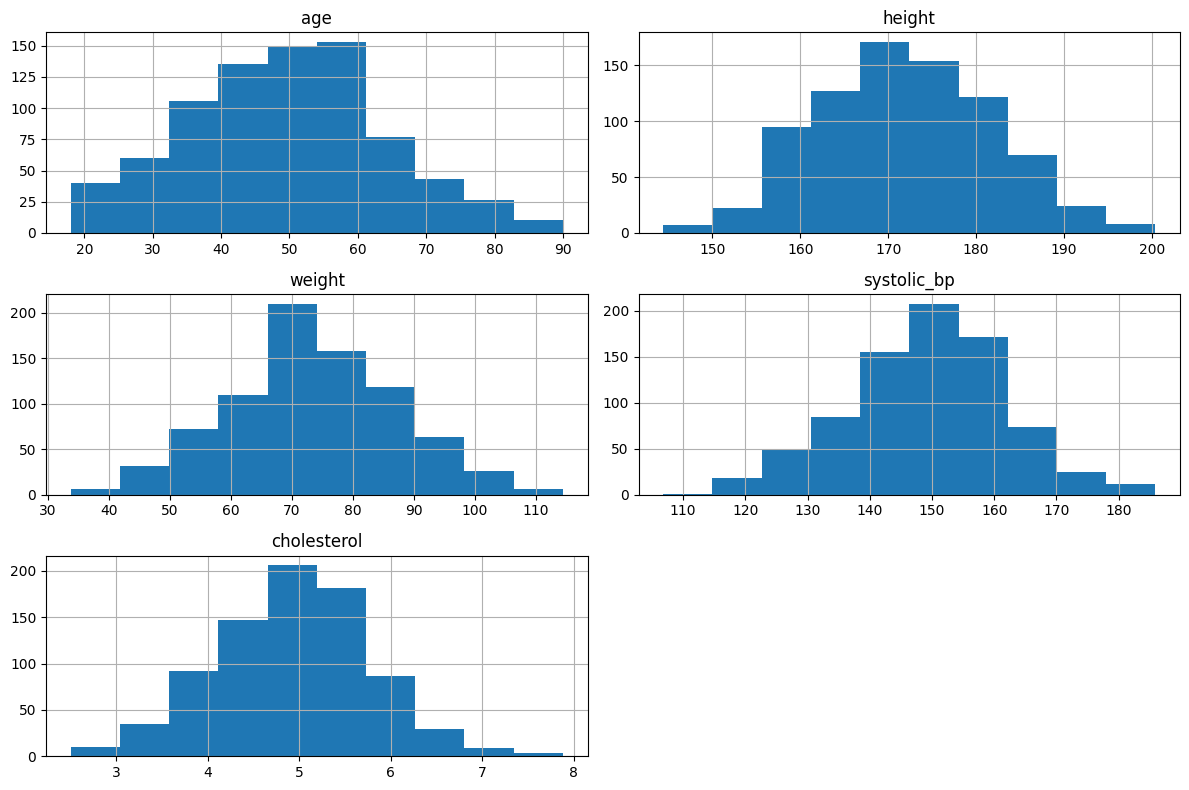

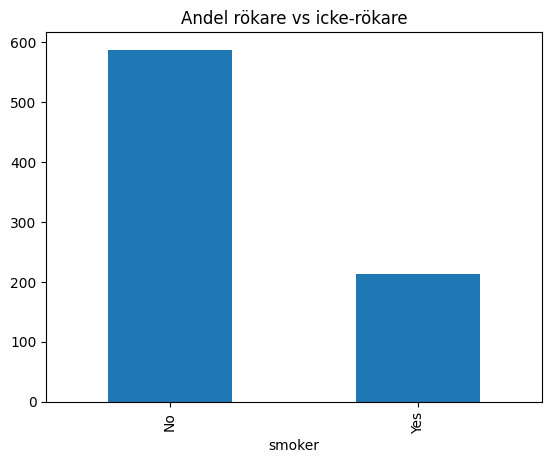

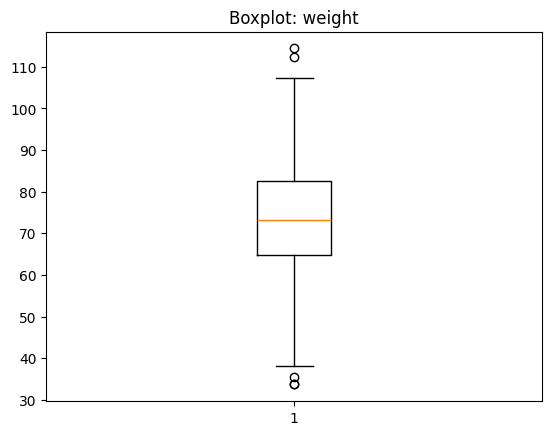

simulerad andel sjuka: 0.056
verkliga sannolikhet: 0.05875
95% konfidence intervalet för systoliskt blodtryck: [ 148.29209036025347   150.06515963974655 ]
En observerad skillnad mellan rökare och icke rökare: 0.47190136846063524
p-värdet: 0.331


In [ ]:
import sys, os
sys.path.append(os.path.abspath('..'))

from src.load_data import load_data
from src.analys import *
from src.health_analys import *

# Läser in datasetet
df = load_data('../data/health_study_dataset.csv')
df.head()

# 1 Beskriver statistik
stats = basic_statistics(df)
print("Statistik:")
print(stats)

# 2 Diagram
plot_histograms(df)
plot_smoker_bar(df)
plot_boxplot(df, "weight")

# 3 Simulering
sim_mean, true_p = simulate_disease_probability(df)
print("simulerad andel sjuka:", sim_mean)
print("verkliga sannolikhet:", true_p)

# 4 Konfidensintervall
lo, hi = confidence_interval_bp(df)
print("95% konfidence intervalet för systoliskt blodtryck: [",lo, " ",hi,"]")

# 5 Hypotesprövning
diff_obs, p_val = hypothesis_test_smokers_higher_bp(df)
print("En observerad skillnad mellan rökare och icke rökare:", diff_obs)
print("p-värdet: ", p_val)

Hypotesprövning delen förklaring.

1. Jag börjar med att räkna ut den verkliga skillnaden i medelblodtryck mellan rökare och icke-rökare.
2. Sedan blandar jag ihop alla blodtrycksvärden slumpmässigt många gånger
3. Vid varje blandning delar jag upp värdena i två nya grupper med samma storlek som rökare/icke-rökare.
4. Jag räknar skillnaden mellan grupperna efter varje blandning.
5. Till sist jämför jag hur många slump skillnader är lika stora eller större än den verkliga skillnaden så
detta get ett p-värde vilket säger hur troligen det är att få en lika stor skillnad bara av slumpen

Snabb slutsats för del 1
I Del 1 har jag utfört en grundläggande statistisk analys av datasetet.
Jag har skapat tre diagram, gjort en simulering och genomfört två statistiska metoder konfidensintervall och hypotesprövning.
Resultaten ger en första förståelse för hur hälsovariablerna är fördelade och hur rökning kan påverka blodtrycket.